# Test Set Evaluation: ResNet50 Car Parts Detector

Evaluates the trained model against the test dataset and compares predictions with ground truth annotations.

In [1]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import hsv_to_rgb
import cv2
import torch
from torchvision.transforms import functional as F
from collections import defaultdict

# Add project root to path
# Find project root by searching for 'src' directory
current = Path(os.getcwd())
while current != current.parent:
    if (current / "src").exists():
        PROJECT_ROOT = current
        break
    current = current.parent
else:
    # Fallback if src not found
    PROJECT_ROOT = Path(os.getcwd()).parent.parent.parent

sys.path.insert(0, str(PROJECT_ROOT))

from src.detection.car_parts.config import CONFIG
from src.detection.common.coco_dataset import build_dataset
from src.detection.common.model import build_model

print(f"Project root: {PROJECT_ROOT}")
print(f"Current working directory: {os.getcwd()}")

Project root: c:\Users\barucroj\Desktop\IPN\TTR\Code\prototipo-deteccion-danos
Current working directory: c:\Users\barucroj\Desktop\IPN\TTR\Code\prototipo-deteccion-danos\tests\detection


## 1. Load Trained Model

In [2]:
CHECKPOINT_PATH = PROJECT_ROOT / "models" / "checkpoints" / "car_parts" / "v1" / "best_model.pth"
SCORE_THRESHOLD = 0.5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Load checkpoint
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
num_classes = checkpoint["num_classes"]
categories = {int(k): v for k, v in checkpoint["categories"].items()}

# Build and load model
model = build_model(num_classes=num_classes, arch=checkpoint.get("arch", "faster_rcnn"), pretrained=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

print(f"✓ Model loaded from {CHECKPOINT_PATH}")
print(f"  Classes: {num_classes}")
print(f"  Epoch: {checkpoint.get('epoch', 'N/A')}")
print(f"  Validation mAP@0.5: {checkpoint.get('val_map50', 'N/A'):.4f}" if 'val_map50' in checkpoint else "")

Device: cuda
✓ Model loaded from c:\Users\barucroj\Desktop\IPN\TTR\Code\prototipo-deteccion-danos\models\checkpoints\gpu_v1\best_model.pth
  Classes: 48
  Epoch: 19
  Validation mAP@0.5: 0.7878


## 2. Load Test Dataset

In [3]:
# Paths come from the detector config so this notebook cannot drift from training.
test_images_dir, test_ann_path = CONFIG.split_paths(
    CONFIG.test_split, data_root=str(PROJECT_ROOT / CONFIG.data_root)
)

test_dataset = build_dataset(
    CONFIG, CONFIG.test_split,
    data_root=str(PROJECT_ROOT / CONFIG.data_root),
    skip_empty=False,
)

print(f"✓ Test dataset loaded")
print(f"  Images: {len(test_dataset)}")
print(f"  Categories: {len(test_dataset.categories)}")

✓ Test dataset loaded
  Images: 16
  Categories: 47


## 3. Run Inference on Test Set

In [4]:
results = []

with torch.no_grad():
    for idx in range(len(test_dataset)):
        image_tensor, target = test_dataset[idx]
        image_tensor = image_tensor.to(device)
        
        # Inference
        output = model([image_tensor])[0]
        
        # Filter by score threshold
        keep = output["scores"] >= SCORE_THRESHOLD
        pred_boxes = output["boxes"][keep].cpu().numpy()
        pred_labels = output["labels"][keep].cpu().numpy()
        pred_scores = output["scores"][keep].cpu().numpy()
        
        # Ground truth
        gt_boxes = target["boxes"].numpy()
        gt_labels = target["labels"].numpy()
        
        results.append({
            "image_idx": idx,
            "image_id": target["image_id"],
            "pred_boxes": pred_boxes,
            "pred_labels": pred_labels,
            "pred_scores": pred_scores,
            "gt_boxes": gt_boxes,
            "gt_labels": gt_labels,
            "num_preds": len(pred_boxes),
            "num_gts": len(gt_boxes),
        })

print(f"✓ Inference complete on {len(results)} test images")

✓ Inference complete on 16 test images


## 4. Compute Metrics

In [5]:
# Basic statistics
total_preds = sum(r["num_preds"] for r in results)
total_gts = sum(r["num_gts"] for r in results)
avg_pred_per_image = total_preds / len(results) if results else 0
avg_gt_per_image = total_gts / len(results) if results else 0

print(f"\n{'='*60}")
print(f"TEST SET EVALUATION SUMMARY")
print(f"{'='*60}")
print(f"Images analyzed: {len(results)}")
print(f"\nDetections:")
print(f"  Total predictions (score >= {SCORE_THRESHOLD}): {total_preds}")
print(f"  Avg predictions per image: {avg_pred_per_image:.2f}")
print(f"\nGround Truth:")
print(f"  Total annotations: {total_gts}")
print(f"  Avg annotations per image: {avg_gt_per_image:.2f}")
print(f"{'='*60}")


TEST SET EVALUATION SUMMARY
Images analyzed: 16

Detections:
  Total predictions (score >= 0.5): 419
  Avg predictions per image: 26.19

Ground Truth:
  Total annotations: 419
  Avg annotations per image: 26.19


## 5. Visualize Sample Predictions

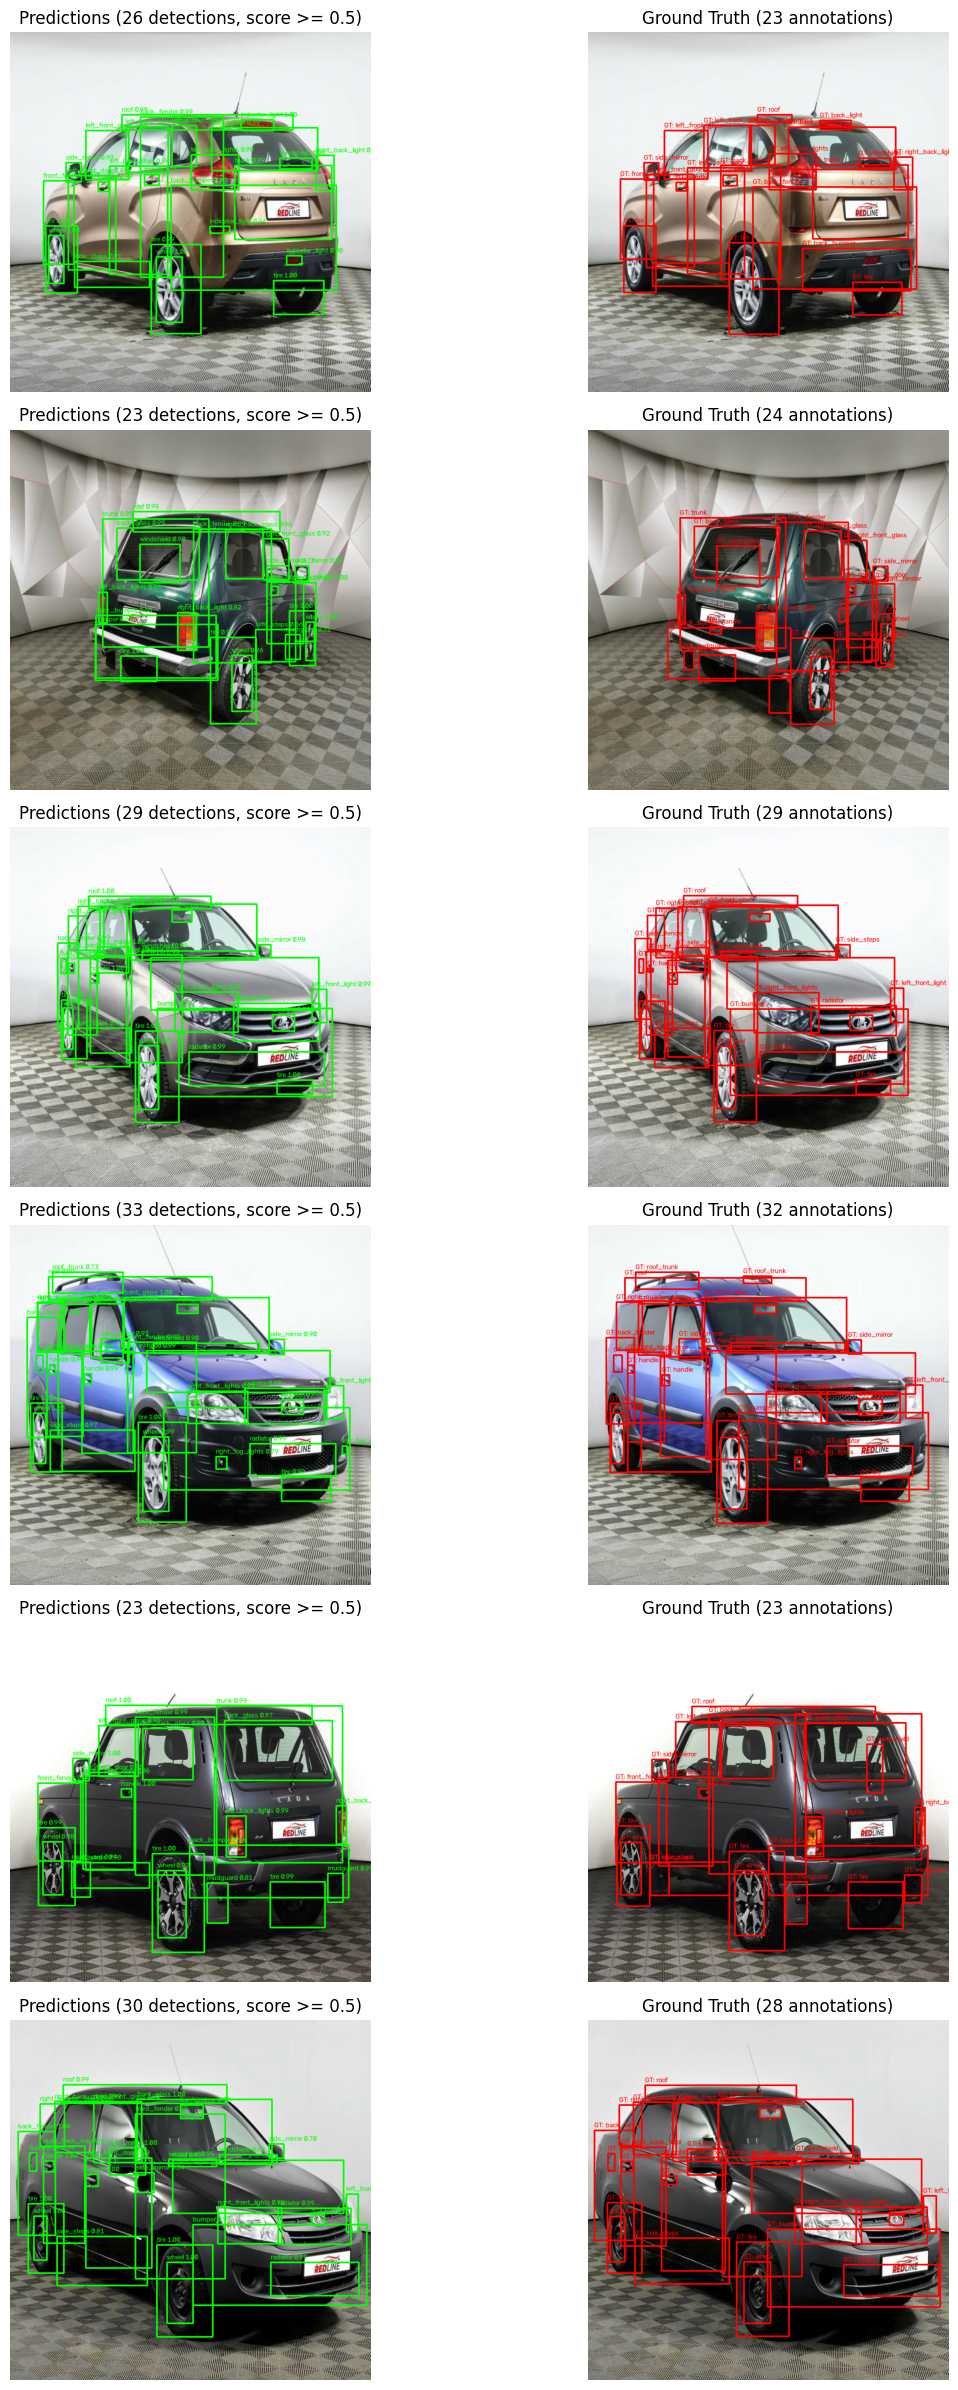

✓ Displayed 6 samples (green=predictions, blue=ground truth)


In [6]:
def draw_boxes(image_rgb, boxes, labels, scores, categories, color, label_prefix=""):
    """Draw bounding boxes on image."""
    image = image_rgb.copy()
    h, w = image.shape[:2]
    
    for box, label, score in zip(boxes, labels, scores if len(scores) > 0 else [None]*len(labels)):
        x1, y1, x2, y2 = [int(v) for v in box]
        x1, y1, x2, y2 = max(0, x1), max(0, y1), min(w, x2), min(h, y2)
        
        cat_name = categories.get(int(label), str(int(label)))
        text = f"{label_prefix}{cat_name}"
        if score is not None:
            text += f" {score:.2f}"
        
        cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
        cv2.putText(image, text, (x1, max(y1-5, 0)), cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1, cv2.LINE_AA)
    
    return image

# Show first 6 test images with predictions vs ground truth
num_samples = min(6, len(results))
fig, axes = plt.subplots(num_samples, 2, figsize=(14, 4*num_samples))
if num_samples == 1:
    axes = axes.reshape(1, -1)

for i, result in enumerate(results[:num_samples]):
    image_idx = result["image_idx"]
    image_tensor, _ = test_dataset[image_idx]
    image_rgb = (image_tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    
    # Predictions (green boxes with scores)
    pred_image = draw_boxes(
        image_rgb, result["pred_boxes"], result["pred_labels"],
        result["pred_scores"], categories, (0, 255, 0), label_prefix=""
    )
    
    # Ground truth (blue boxes without scores)
    gt_image = draw_boxes(
        image_rgb, result["gt_boxes"], result["gt_labels"],
        np.array([]), categories, (255, 0, 0), label_prefix="GT: "
    )
    
    axes[i, 0].imshow(pred_image)
    axes[i, 0].set_title(f"Predictions ({result['num_preds']} detections, score >= {SCORE_THRESHOLD})")
    axes[i, 0].axis("off")
    
    axes[i, 1].imshow(gt_image)
    axes[i, 1].set_title(f"Ground Truth ({result['num_gts']} annotations)")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()
print(f"✓ Displayed {num_samples} samples (green=predictions, blue=ground truth)")

## 6. Distribution Analysis

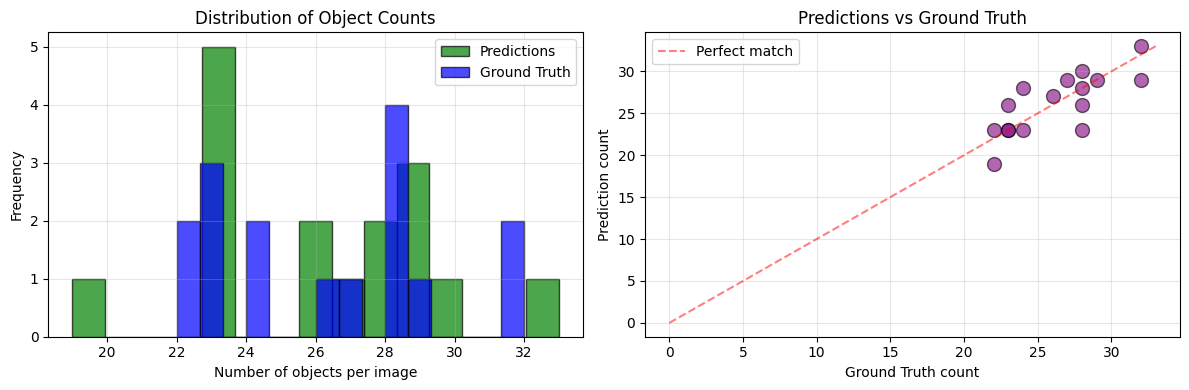


Detection Statistics:
  Predictions - Min: 19, Max: 33, Mean: 26.19
  Ground Truth - Min: 22, Max: 32, Mean: 26.19


In [7]:
# Detection counts per image
pred_counts = [r["num_preds"] for r in results]
gt_counts = [r["num_gts"] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of detections
axes[0].hist(pred_counts, bins=15, alpha=0.7, label="Predictions", color="green", edgecolor="black")
axes[0].hist(gt_counts, bins=15, alpha=0.7, label="Ground Truth", color="blue", edgecolor="black")
axes[0].set_xlabel("Number of objects per image")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Object Counts")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Scatter: predictions vs ground truth
axes[1].scatter(gt_counts, pred_counts, alpha=0.6, s=100, color="purple", edgecolor="black")
max_val = max(max(gt_counts), max(pred_counts)) if pred_counts and gt_counts else 10
axes[1].plot([0, max_val], [0, max_val], "r--", alpha=0.5, label="Perfect match")
axes[1].set_xlabel("Ground Truth count")
axes[1].set_ylabel("Prediction count")
axes[1].set_title("Predictions vs Ground Truth")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nDetection Statistics:")
print(f"  Predictions - Min: {min(pred_counts)}, Max: {max(pred_counts)}, Mean: {np.mean(pred_counts):.2f}")
print(f"  Ground Truth - Min: {min(gt_counts)}, Max: {max(gt_counts)}, Mean: {np.mean(gt_counts):.2f}")

## 7. Per-Class Performance

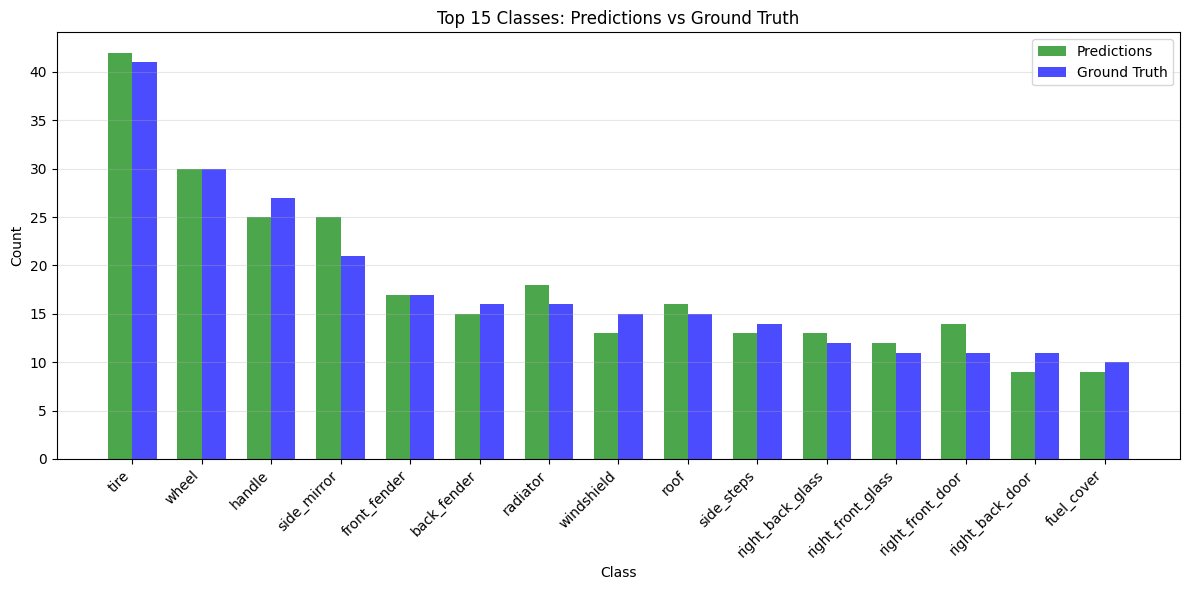


Top 10 Classes by Ground Truth Count:
  tire                           - GT:  41, Pred:  42 (ratio: 1.02)
  wheel                          - GT:  30, Pred:  30 (ratio: 1.00)
  handle                         - GT:  27, Pred:  25 (ratio: 0.93)
  side_mirror                    - GT:  21, Pred:  25 (ratio: 1.19)
  front_fender                   - GT:  17, Pred:  17 (ratio: 1.00)
  back_fender                    - GT:  16, Pred:  15 (ratio: 0.94)
  radiator                       - GT:  16, Pred:  18 (ratio: 1.12)
  windshield                     - GT:  15, Pred:  13 (ratio: 0.87)
  roof                           - GT:  15, Pred:  16 (ratio: 1.07)
  side_steps                     - GT:  14, Pred:  13 (ratio: 0.93)


In [8]:
# Count predictions and GTs per class
pred_by_class = defaultdict(int)
gt_by_class = defaultdict(int)

for result in results:
    for label in result["pred_labels"]:
        pred_by_class[label] += 1
    for label in result["gt_labels"]:
        gt_by_class[label] += 1

# Get top 15 classes by ground truth count
top_classes = sorted(gt_by_class.items(), key=lambda x: x[1], reverse=True)[:15]
top_class_ids = [c[0] for c in top_classes]

class_names = [categories.get(cid, f"Class {cid}") for cid in top_class_ids]
pred_counts_top = [pred_by_class.get(cid, 0) for cid in top_class_ids]
gt_counts_top = [gt_by_class[cid] for cid in top_class_ids]

# Bar chart
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(class_names))
width = 0.35

bars1 = ax.bar(x - width/2, pred_counts_top, width, label="Predictions", color="green", alpha=0.7)
bars2 = ax.bar(x + width/2, gt_counts_top, width, label="Ground Truth", color="blue", alpha=0.7)

ax.set_xlabel("Class")
ax.set_ylabel("Count")
ax.set_title("Top 15 Classes: Predictions vs Ground Truth")
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTop 10 Classes by Ground Truth Count:")
for cid, count in top_classes[:10]:
    pred_count = pred_by_class.get(cid, 0)
    class_name = categories.get(cid, f"Class {cid}")
    ratio = pred_count / count if count > 0 else 0
    print(f"  {class_name:30s} - GT: {count:3d}, Pred: {pred_count:3d} (ratio: {ratio:.2f})")

## 8. Confidence Score Distribution

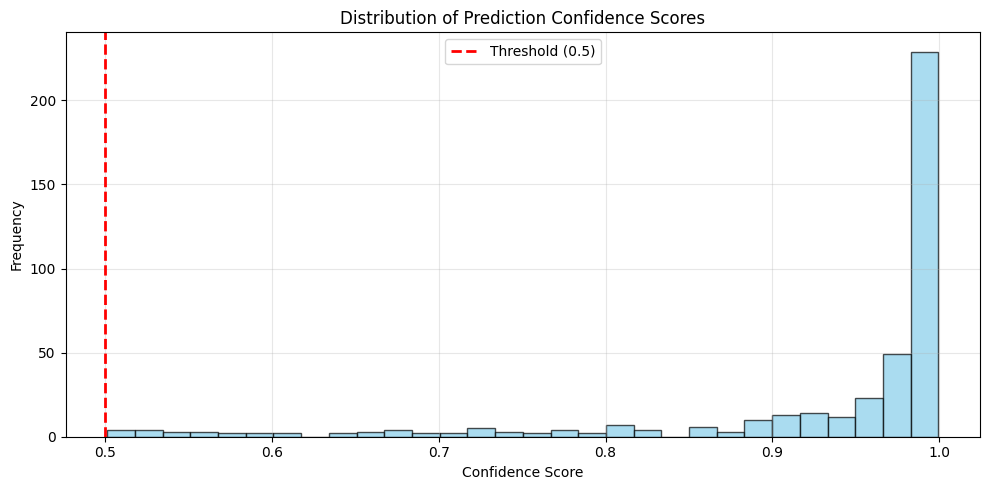


Confidence Score Statistics:
  Count: 419
  Mean: 0.9331
  Min: 0.5012
  Max: 0.9995
  Std: 0.1146


In [9]:
all_scores = []
for result in results:
    all_scores.extend(result["pred_scores"])

if all_scores:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(all_scores, bins=30, color="skyblue", edgecolor="black", alpha=0.7)
    ax.axvline(SCORE_THRESHOLD, color="red", linestyle="--", linewidth=2, label=f"Threshold ({SCORE_THRESHOLD})")
    ax.set_xlabel("Confidence Score")
    ax.set_ylabel("Frequency")
    ax.set_title("Distribution of Prediction Confidence Scores")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\nConfidence Score Statistics:")
    print(f"  Count: {len(all_scores)}")
    print(f"  Mean: {np.mean(all_scores):.4f}")
    print(f"  Min: {np.min(all_scores):.4f}")
    print(f"  Max: {np.max(all_scores):.4f}")
    print(f"  Std: {np.std(all_scores):.4f}")
else:
    print("No predictions with sufficient confidence scores.")

## Summary

In [10]:
print(f"\n{'='*60}")
print(f"EVALUATION COMPLETE")
print(f"{'='*60}")
print(f"Model: ResNet50-FPN v2")
print(f"Checkpoint: {CHECKPOINT_PATH}")
print(f"Test images: {len(results)}")
print(f"Score threshold: {SCORE_THRESHOLD}")
print(f"\nTotal objects:")
print(f"  Predictions: {total_preds}")
print(f"  Ground Truth: {total_gts}")
print(f"\nCoverage: {total_preds / total_gts * 100:.1f}% of GT objects detected")
print(f"Precision estimate: {total_preds / total_gts if total_gts > 0 else 0:.2f} predictions per GT object")
print(f"{'='*60}")


EVALUATION COMPLETE
Model: ResNet50-FPN v2
Checkpoint: c:\Users\barucroj\Desktop\IPN\TTR\Code\prototipo-deteccion-danos\models\checkpoints\gpu_v1\best_model.pth
Test images: 16
Score threshold: 0.5

Total objects:
  Predictions: 419
  Ground Truth: 419

Coverage: 100.0% of GT objects detected
Precision estimate: 1.00 predictions per GT object
